In [304]:
import sisl
import matplotlib.pyplot as plt
import numpy as np
from ase.visualize import view
from mytools.plots import thesis_fig

from ipywidgets import HTML
from matplotlib.animation import FuncAnimation

In [305]:
BOND = 1.42
S2 = 8
S1 = 4

gr2 = sisl.geom.graphene_flake(shells=S2, bond=BOND, vacuum=10)
gr2 = gr2.translate(-gr2.center())
gr1 = sisl.geom.graphene_flake(shells=S1, bond=BOND, vacuum=10)
gr1 = gr1.translate(-gr1.center())

636
Lines: 1
Collections (Scatters): 1
Images: 0


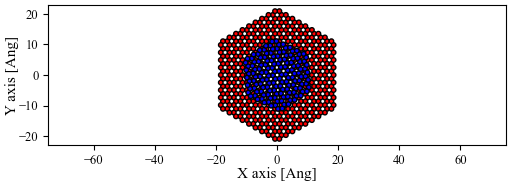

In [294]:
qtm = gr2.translate([0., 0., -5]) + gr1.rotate([5, [0,0,1]])

astyle=[
    dict(atoms=range(gr2.na), color="red"),
    dict(atoms=range(gr2.na, qtm.na), color="blue")
]

fig = qtm.plot(axes="xy", atoms_style=astyle, backend="matplotlib", show_cell=False)
ax = fig.gca()

print(qtm.na)
print(f"Lines: {len(ax.lines)}")
print(f"Collections (Scatters): {len(ax.collections)}")
print(f"Images: {len(ax.images)}")


/tmp/ipykernel_197903/1938145917.py:65: UserWarning:

constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.



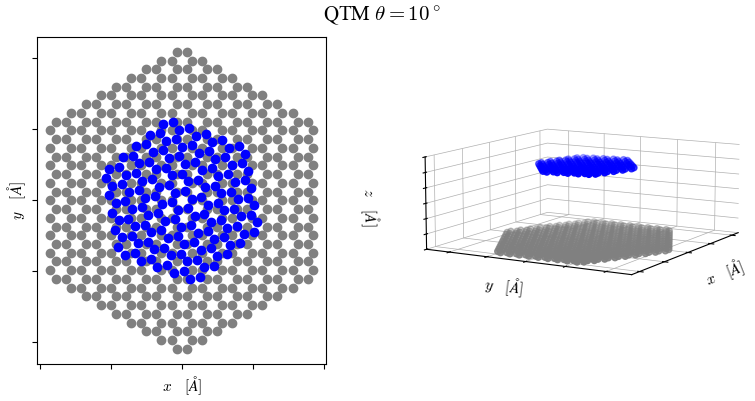

In [ ]:


# scat = ax.collections[0]
# lines = ax.lines
# print(lines)
# offsets =scat.get_offsets()

# x_data = offsets[:, 0]
# y_data = offsets[:, 1]
# colors_rgba = scat.get_facecolors()
# print(colors_rgba)
# sizes = scat.get_sizes()



rot = 10
qtm = gr2 + gr1.rotate([rot, [0,0,1]])

x_data, y_data = qtm.xyz[:, :2].T

subplots = (1,2)
upper_layer = 'blue'
lower_layer = 'grey'
fig, (ax2D, axes) = thesis_fig(subplots=subplots, figsize=(8,4))
axes.remove()
axes = fig.add_subplot(*subplots,2, projection="3d")

ax2D.scatter(x_data[:gr2.na], y_data[:gr2.na], c=lower_layer, alpha=1)
ax2D.scatter(x_data[gr2.na:], y_data[gr2.na:], c=upper_layer, alpha=1)
ax2D.set(aspect=1,
         xlabel=r"$ x\quad [\AA]$",
         ylabel=r"$ y\quad [\AA]$",
        #  zlabel=r"$ z\quad [\AA]$",
         xticklabels="",
         yticklabels="",
        #  zticklabels="",
        #  box_aspect=(1,1,0.5),
         
         )
    
    
# plot atoms for both layers
axes.scatter(x_data[:gr2.na], y_data[:gr2.na], zs=0, c=lower_layer,)
axes.scatter(x_data[gr2.na:], y_data[gr2.na:], zs=5, c=upper_layer,)

axes.set(zlim=(0,6),
        #  title="QTM",
         xlabel=r"$ x\quad [\AA]$",
         ylabel=r"$ y\quad [\AA]$",
         zlabel=r"$ z\quad [\AA]$",
         xticklabels="",
         yticklabels="",
         zticklabels="",
         box_aspect=(1,1,0.4),
         ) 



axes.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
axes.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
axes.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
axes.view_init(elev=10, azim=30)
axes.margins(x=0.1, y=0.1, z=0.1)

fig.set_constrained_layout(True)
fig.suptitle(rf"QTM $\theta = {rot}^\circ$")
fig.savefig("../figures/QTM")

In [ ]:
# 1. Setup the initial figure using your wrapper
# We call rot_plot once to initialize the axes and objects
# Or just manually set up ax2d and ax3d
fig, (ax2d, ax3d_temp) = thesis_fig(subplots=(1,2), figsize=(8,4))

# Handle the 3D replacement hack
ax3d_temp.remove()
ax3d = fig.add_subplot(1, 2, 2, projection="3d")

# Initialize empty scatter objects that we will update
scat2d_1 = ax2d.scatter([], [], c='blue')
scat2d_2 = ax2d.scatter([], [], c='grey')

scat3d_1 = ax3d.scatter([], [], [], c='blue')
scat3d_2 = ax3d.scatter([], [], [], c='grey')

# Formatting (boilerplate from your rot_plot function)
ax2d.set(aspect=1, xlim=(-15, 15), ylim=(-15, 15)) # Set fixed limits for animation!
ax3d.set(zlim=(0, 6), xlim=(-15, 15), ylim=(-15, 15), box_aspect=(1,1,0.4))
ax3d.view_init(elev=30, azim=30)

def update(frame_angle):
    """This function runs for every frame of the animation"""
    
    # Apply rotation to gr1 (copy it so we don't mutate original)
    temp_gr1 = gr1.translate(-gr1.center()).rotate([frame_angle, [0,0,1]])
    xy1 = temp_gr1.xyz[:, :2]
    
    # gr2 is static
    temp_gr2 = gr2.translate(-gr2.center())
    xy2 = temp_gr2.xyz[:, :2]

    # Update 2D data
    scat2d_1.set_offsets(xy1)
    scat2d_2.set_offsets(xy2)

    # Update 3D data (3D requires setting offsets and then zs separately)
    scat3d_1.set_offsets(xy1)
    # Note: in some MPL versions you use .set_3d_properties()
    scat3d_1.set_3d_properties(np.full(len(xy1), 5), 'z')
    
    scat3d_2.set_offsets(xy2)
    scat3d_2.set_3d_properties(np.zeros(len(xy2)), 'z')
    
    return scat2d_1, scat2d_2, scat3d_1, scat3d_2

# 3. Create the animation
# frames: sequence of angles (e.g., 0 to 60 degrees)
angles = np.linspace(0, 60, 120) 

ani = FuncAnimation(fig, update, frames=angles, blit=True, interval=50)

# 4. Save as GIF (requires 'pillow' or 'imagemagick' installed)
ani.save('moire_rotation.gif', writer='pillow', fps=100)

plt.show()

In [303]:
def rot_plot(gr1, gr2, rot, colors=['blue', 'grey']):
        gr1 = gr1.translate(-gr1.center())
        gr1 = gr1.rotate([rot, [0,0,1]])
        xy1 = gr1.xyz[:, :2].T
        
        gr2 = gr2.translate(-gr2.center())
        xy2 = gr2.xyz[:, :2].T
        
        
        subplots=(1,2)
        figsize=(8,4)
        fig, (ax2d, ax3d) = thesis_fig(subplots=subplots, figsize=figsize)
        
        ax2d.scatter(*xy1.T, c=colors[0], alpha=1)
        ax2d.scatter(*xy2.T, c=colors[1], alpha=1)
        ax2d.set(aspect=1,
                xlabel=r"$ x\quad [\AA]$",
                ylabel=r"$ y\quad [\AA]$",
                #  zlabel=r"$ z\quad [\AA]$",
                xticklabels="",
                yticklabels="",
                #  zticklabels="",
                #  box_aspect=(1,1,0.5),    
        )        
        
        ax3d.remove()
        ax3d = fig.add_subplot(*subplots,2, projection="3d")
        
        # plot atoms for both layers
        ax3d.scatter(*xy1.T, zs=0, c=colors[0],)
        ax3d.scatter(*xy2.T, zs=5, c=colors[1],)

        ax3d.set(zlim=(0,6),
                #  title="QTM",
                xlabel=r"$ x\quad [\AA]$",
                ylabel=r"$ y\quad [\AA]$",
                zlabel=r"$ z\quad [\AA]$",
                xticklabels="",
                yticklabels="",
                zticklabels="",
                box_aspect=(1,1,0.4),
                ) 



        ax3d.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax3d.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax3d.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
        ax3d.view_init(elev=30, azim=30)
        ax3d.margins(x=0.1, y=0.1, z=0.1)

        fig.set_constrained_layout(True)
        